# Data Cleaning

Loads raw and processed data, checks quality, computes log returns, and visualises distributions.

**Survivorship bias note:** The universe is built from current S&P 500 constituents. The analysis is subject to survivorship bias and should be interpreted as an empirical test rather than a production-ready strategy.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

RAW = "../data/raw"
PROCESSED = "../data/processed"
INTERIM = "../data/interim"

Check how many tickers were downloaded vs retained and the final date range.

In [11]:
prices = pd.read_parquet(f"{PROCESSED}/sp500_liquid_adj_close.parquet")
universe = pd.read_csv(f"{PROCESSED}/ticker_universe.csv")
adj_close_raw = pd.read_parquet(f"{RAW}/sp500_adj_close_raw.parquet")

print(f"Tickers downloaded : {len(adj_close_raw.columns)}")
print(f"Tickers retained   : {len(universe)}")
print(f"Date range         : {prices.index.min().date()}  →  {prices.index.max().date()}")
print(f"Trading days       : {len(prices)}")

Tickers downloaded : 502
Tickers retained   : 200
Date range         : 2011-06-24  →  2026-04-27
Trading days       : 3731


Missing fractions computed from the full raw download before the liquidity filter. Stocks with > 5% missing observations are dropped.

In [12]:
missing_frac = adj_close_raw.isna().mean().sort_values(ascending=False)
missing_count = adj_close_raw.isna().sum()

print(f"Tickers with >5% missing : {(missing_frac > 0.05).sum()}")
print(f"Tickers with ≤5% missing : {(missing_frac <= 0.05).sum()}")
print()

missing_summary = pd.DataFrame({
    "missing_fraction": missing_frac,
    "missing_count": missing_count,
}).head(20)
missing_summary.style.format({"missing_fraction": "{:.2%}"})

Tickers with >5% missing : 64
Tickers with ≤5% missing : 438



,missing_fraction,missing_count
Ticker,,
A,0.00%,0
AAPL,0.00%,0
ABBV,13.04%,502
ABNB,64.97%,2502
ABT,0.00%,0
ACGL,0.00%,0
ACN,0.00%,0
ADBE,0.00%,0
ADI,0.00%,0


Log returns: $r_{i,t} = \log(P_{i,t}) - \log(P_{i,t-1})$. Winsorised at the 1st / 99th percentile per stock to cap outliers.

In [13]:
log_returns = np.log(prices / prices.shift(1)).dropna(how='all')

q_lo = log_returns.quantile(0.01)
q_hi = log_returns.quantile(0.99)
log_returns_win = log_returns.clip(lower=q_lo, upper=q_hi, axis=1)

print(f"Observations: {log_returns_win.shape[0]} days × {log_returns_win.shape[1]} stocks")
print()
log_returns_win.stack().describe().rename("log_return (pooled)")

Observations: 3730 days × 200 stocks



count    746000.000000
mean          0.000610
std           0.017904
min          -0.105497
25%          -0.008091
50%           0.000781
75%           0.009645
max           0.120467
Name: log_return (pooled), dtype: float64

Return Distribution pooled across all stocks and dates. A normal fit is overlaid — equity returns typically show excess kurtosis (fat tails).

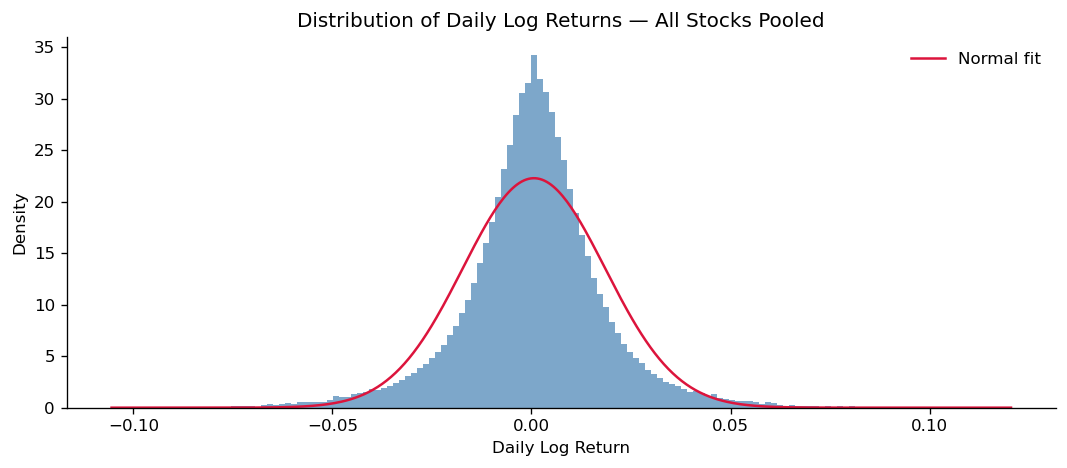

In [14]:
pooled = log_returns_win.values.flatten()
pooled = pooled[~np.isnan(pooled)]

mu, sigma = pooled.mean(), pooled.std()
x = np.linspace(pooled.min(), pooled.max(), 400)
normal_pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pooled, bins=150, density=True, color="steelblue", alpha=0.7, edgecolor="none")
ax.plot(x, normal_pdf, color="crimson", linewidth=1.5, label="Normal fit")
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Density")
ax.set_title("Distribution of Daily Log Returns — All Stocks Pooled")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Example Price Chart

Prices rebased to 1.0 at the start of the sample for comparability.

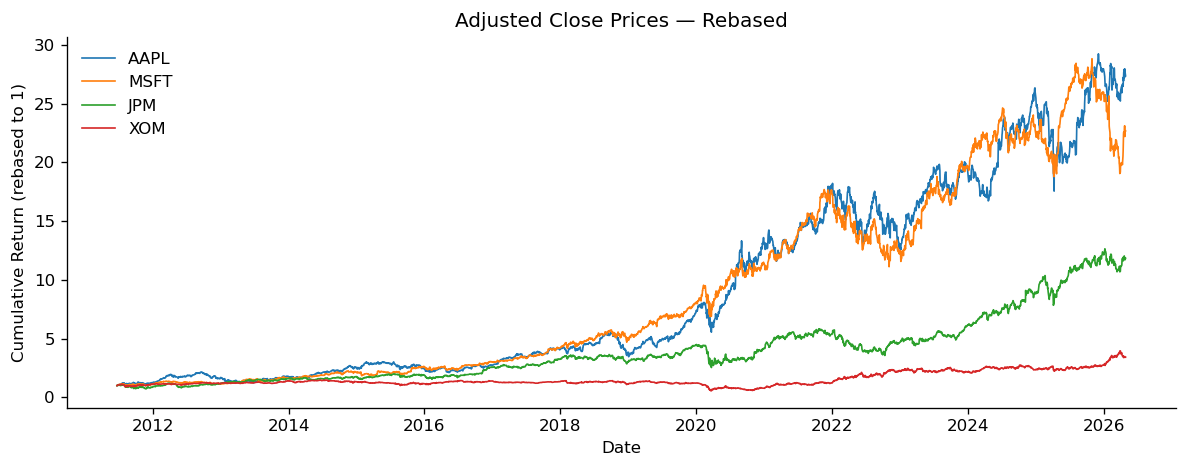

In [15]:
example_tickers = [t for t in ["AAPL", "MSFT", "JPM", "XOM"] if t in prices.columns]

fig, ax = plt.subplots(figsize=(10, 4))
for ticker in example_tickers:
    rebased = prices[ticker] / prices[ticker].iloc[0]
    ax.plot(prices.index, rebased, label=ticker, linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (rebased to 1)")
ax.set_title("Adjusted Close Prices — Rebased")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Example Return Chart

Daily log returns for the same stocks. Volatility clustering is visible.

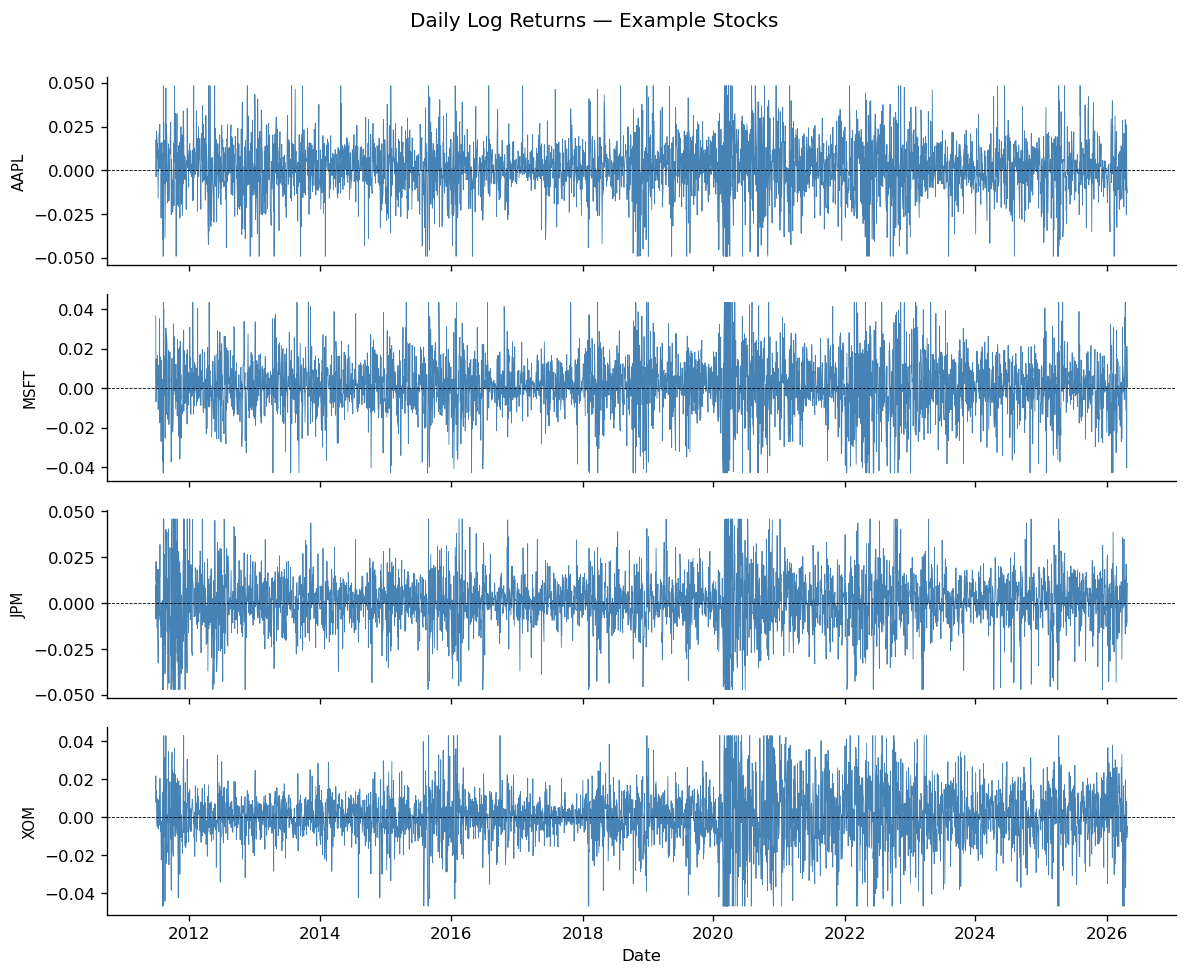

In [17]:
fig, axes = plt.subplots(len(example_tickers), 1, figsize=(10, 2 * len(example_tickers)), sharex=True)
if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    ax.plot(log_returns_win.index, log_returns_win[ticker], linewidth=0.5, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel(ticker, fontsize=9)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Log Returns — Example Stocks", y=1.01)
plt.tight_layout()
plt.show()